## Target mainīgais: PageValues — lapas vērtība, kas atspoguļo, cik tuvu klients bija pirkuma veikšanai. Augstāka vērtība = augstāka pirkuma varbūtība un vērtība. ##

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ielādē 2. nedēļā sagatavoto tīro datu kopu
df = pd.read_csv('shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")

Datu kopa: 12330 rindas, 30 kolonnas


PageValues statistika:
count    12330.000000
mean         5.889258
std         18.568437
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        361.763742
Name: PageValues, dtype: float64


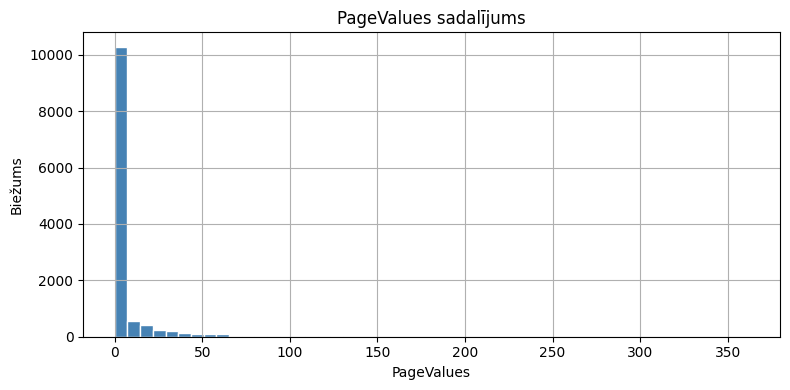

In [2]:
# Apskatām target mainīgo
print("PageValues statistika:")
print(df['PageValues'].describe())

plt.figure(figsize=(8, 4))
df['PageValues'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('PageValues sadalījums')
plt.xlabel('PageValues')
plt.ylabel('Biežums')
plt.tight_layout()
plt.show()

In [3]:
# Target
y = df['PageValues']

# Features — visas kolonnas, izņemot PageValues un Revenue
# (Revenue nedrīkst izmantot, jo tā ir "nākotnes" informācija — data leakage!)
X = df.drop(['PageValues', 'Revenue'], axis=1)

print(f"Features skaits: {X.shape[1]}")
print(f"Target: PageValues")

Features skaits: 28
Target: PageValues


**Kāpēc jaizņem kolonna Revenue no features? Kas ir data leakage un kāpēc tas ir bīstami?**

*Kolonna Revenue jāizņem no features (ievaddatiem), jo tā ir prognozētā nākotnes vērtība/ieņēmumi. Ja modelim iedod pieņēmumu/prognozi kā faktu, tad tiks radīti mākslīgi labi rezultāti jeb notiek **Data leakage**, jo modelis no tā neko nemācās.*

**Bīstamība**

- **Mākslīgi augsta precizitāte** -> *Modelis izskatās perfekts treniņā, bet reālajā pasaulē ir bezjēdzīgs*

- **Nepareizi lēmumi** -> *Uzņēmums pieņem lēmumus, balstoties uz neuzticamiem rezultātiem*

- **Neiespējami atkārtot** -> *Modelis nestrādā produkcijā, jo trūkst "noplūdušās" informācijas*

- **Slēpta kļūda** -> *Problēmu ir grūti pamanīt — viss izskatās labi uz papīra*


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")

Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Izveido un uztrenē modeli
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prognozes
y_pred = lr_model.predict(X_test)

# Metrikas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Lineārā regresija: rezultāti ===")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

=== Lineārā regresija: rezultāti ===
MSE:  338.5721
RMSE: 18.4003
MAE:  9.2073
R²:   0.0524


**1.Ko nozīmē MSE (Mean Squared Error)? Kāpēc lielākas kļūdas tiek sodītas vairāk?**

*MSE (Vidējā kvadrātiskā kļūda) parāda, cik tālu vidēji modelis kļūdās savās prognozēs. Katra kļūda (starpība starp īsto un prognozēto) tiek kāpināta kvadrātā, lai negatīvā (kad prognoze bija zemāka) un pozitīvā (kad prognoze bija augstāka) kļūda neatceļ viena otru un lai lielās kļūdas tiktu sodītas vairāk. Sodot lielās kļūdas vairāk, modelis treniņa laikā cenšas īpaši izvairīties no lieliem sitieniem garām, nevis vienkārši minimizē kļūdu skaitu. Tā kā lielās kļūdas ir dārgākas reālajā pasaulē, modelis jātrenē no tādām izvairīties. Jo mazāks MSE, jo labāks modelis*

*Tā kā MSE ir absolūts skaitlis (eiro kavdrātā), kas nav interpretējams, no tā ir jāizvelk sakne jeb RMSE, kas ir EUR izteiksmē un atspoguļo vērtības nobīdi. Mūsu gadījumā modelis vidēji kļūdās par 18.40 EUR, kur lielās kļūdas ietekmē vairāk. Ja pieņemam, ka visas kļūdas ir vienlīdzīgas, tad vidējā kļūda jeb MAE ir 9.20 EUR*

**2.Ko nozīmē R² (R-squared)? Ko nozīmē vērtība, ko tu ieguvi?**

*Determinācijas koeficients jeb, vienkāršiem vārdiem sakot, cik daudz no "notiekošā" datos modelis saprot. Ja vērtība ir tuvu nullei jeb 0.0, tad modelis ir vājš, ja tuvu 1.0, tad ļoti labs un kļūdu nav. Šajā gadījumā koeficients ir tikai 0.0524, kas nozīmē, ka modelis ir vājš.

**3.Vai modelis ir labs vai slikts? Kāpēc tu tā domā?**

*Modelis ir slikts, jo spēj izskaidrot tikai 5% no visiem mainīgajiem. Noteikti nedrīkst izmantot e-komercijas prognozēm. Jāmaina modelis, jo lineārā regresija neder jeb nav iespējams novilkt taisnu līniju (punkti pārāk izkliedēti).*

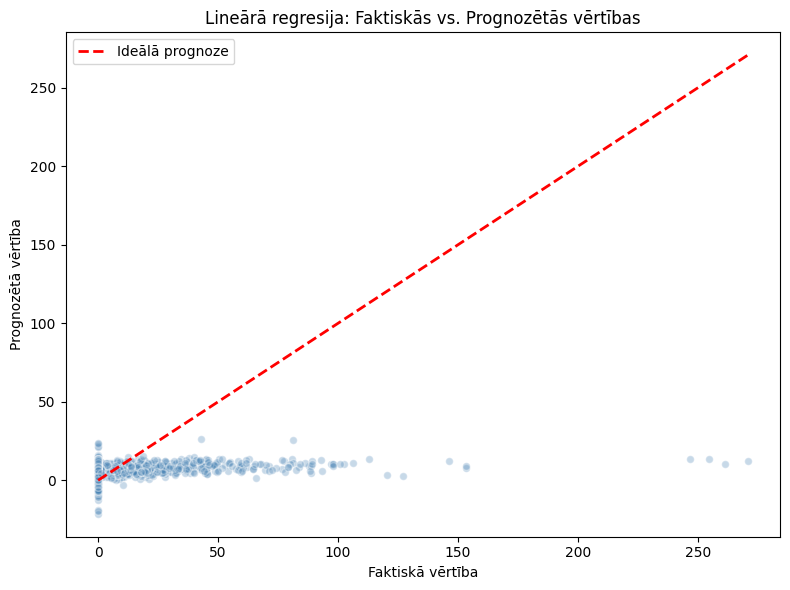

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='white', s=30)

# Ideālā līnija (ja prognoze = realitāte)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideālā prognoze')

plt.xlabel('Faktiskā vērtība')
plt.ylabel('Prognozētā vērtība')
plt.title('Lineārā regresija: Faktiskās vs. Prognozētās vērtības')
plt.legend()
plt.tight_layout()
plt.show()

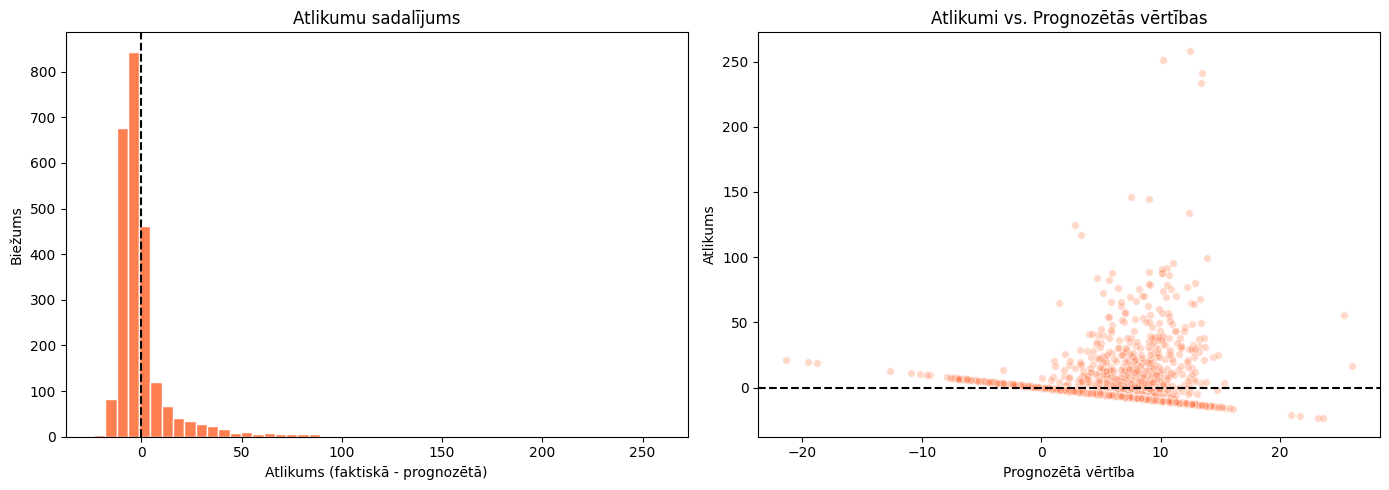

In [7]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Atlikumu sadalījums
axes[0].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[0].set_title('Atlikumu sadalījums')
axes[0].set_xlabel('Atlikums (faktiskā - prognozētā)')
axes[0].set_ylabel('Biežums')
axes[0].axvline(x=0, color='black', linestyle='--')

# Atlikumi vs. prognozētās vērtības
axes[1].scatter(y_pred, residuals, alpha=0.3, color='coral', edgecolors='white', s=30)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title('Atlikumi vs. Prognozētās vērtības')
axes[1].set_xlabel('Prognozētā vērtība')
axes[1].set_ylabel('Atlikums')

plt.tight_layout()
plt.show()

**1.Vai punkti scatter grafikā ir tuvu sarkanai līnijai? Ko tas nozīmē?**

*Nē, punkti ir tālu no sarkanās līnijas. Ja modelis būtu perfekts, visi zilie punkti būtu tieši uz tā.*

*Visi punkti "saspiesti" apakšā (Y ass 0–25) -> Neatkarīgi no tā, kāda ir faktiskā vērtība (pat 150, 250), modelis gandrīz vienmēr prognozē ~0–15. Modelis ir "slinks" — tas vienkārši prognozē apmēram vidējo vērtību visiem.*

*Datos ir liela variācija — vērtības ir ļoti dažādas. Modelis to neredz un nespēj izskaidrot.*

*Modelis nav iemācījies nekādu jēgpilnu sakarību starp features un mērķi. Tas "uzmin" aptuveni vienu un to pašu skaitli visiem gadījumiem.*

**2.Vai atlikumi ir vienmērīgi sadalīti ap 0? Vai ir kāds skaidrs modelis (pattern)?**

*Nē, sadalījums nav vienmērīgs ap 0. Ideālā gadījumā vajadzētu redzēt simetrisku zvana formu ap 0. Šeit sadalījums ir stipri šķībs.*

*Jā, ir skaidrs pattern un tas ir slikti. Pie zemām prognozētajām vērtībām (~0–15) atlikumi ir ļoti izkaisīti (gan +250, gan -20). Punkti veido skaidru konusa/trīsstūra formu. Ideālā gadījumā punktiem vajadzētu būt haotiski izkaisītiem ap 0 bez jebkāda pattern.

**3.Ko vizualizācijas stāsta par modeļa kvalitāti?**

*1)Modelis sistemātiski nenovērtē lielas vērtības*

*2)Kļūdas pieaug līdz ar vērtību — modelis nav stabils*

*3)Lineārā regresija nespēj uztvert datu struktūru*

*Grafiki norāda, ka izvēlēts nepareizs modeļa tips. Dati satur nelineāras sakarības.*

In [8]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

# Metrikas
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Random Forest Regressor: rezultāti ===")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²:   {r2_rf:.4f}")

=== Random Forest Regressor: rezultāti ===
RMSE: 18.1519
R²:   0.0778


In [9]:
comparison = pd.DataFrame({
    'Modelis': ['Lineārā regresija', 'Random Forest'],
    'RMSE': [rmse, rmse_rf],
    'R²': [r2, r2_rf]
})

print(comparison.to_string(index=False))

          Modelis     RMSE       R²
Lineārā regresija 18.40033 0.052425
    Random Forest 18.15195 0.077834


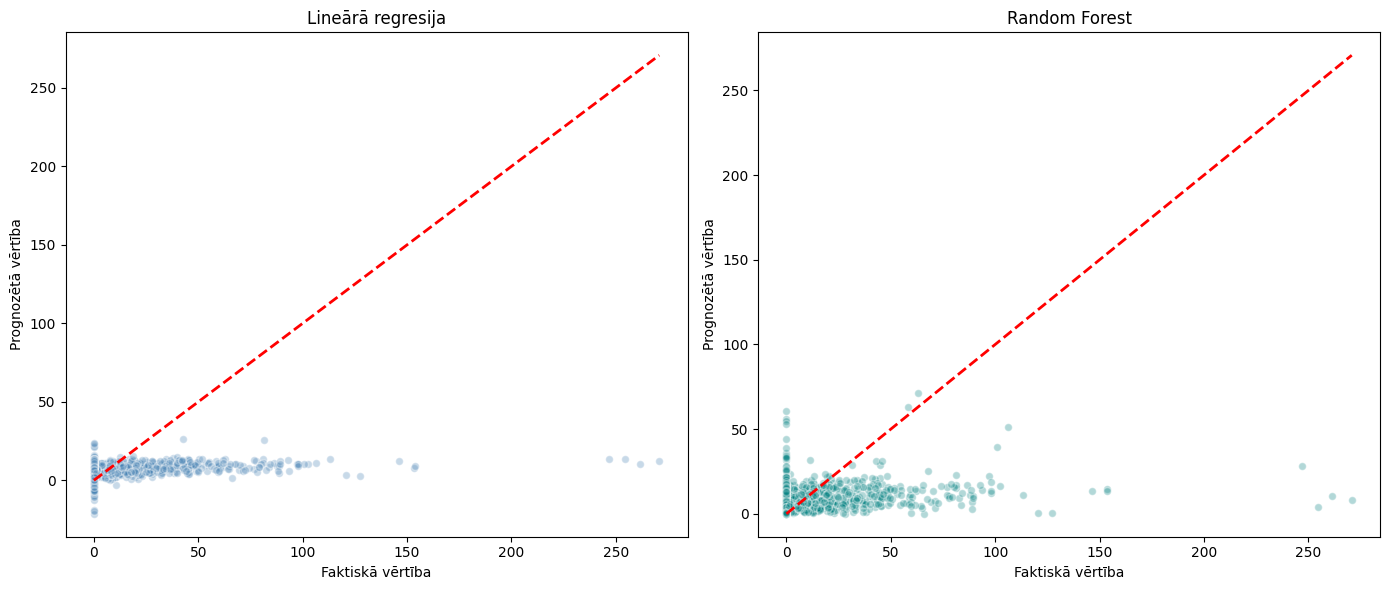

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, pred, title, color in [
    (axes[0], y_pred, 'Lineārā regresija', 'steelblue'),
    (axes[1], y_pred_rf, 'Random Forest', 'teal')
]:
    ax.scatter(y_test, pred, alpha=0.3, color=color, edgecolors='white', s=30)
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2)
    ax.set_xlabel('Faktiskā vērtība')
    ax.set_ylabel('Prognozētā vērtība')
    ax.set_title(title)

plt.tight_layout()
plt.show()

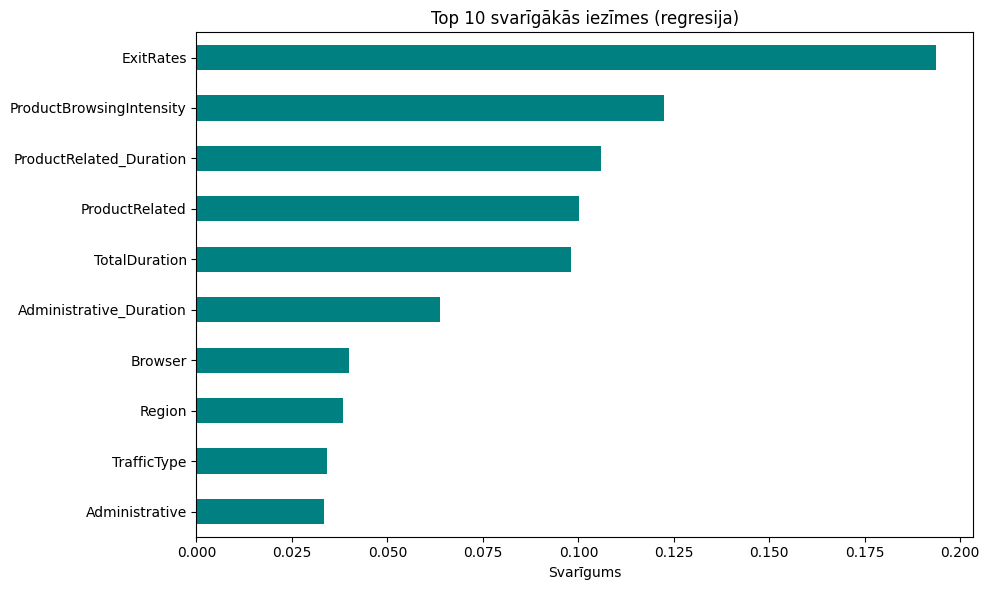

In [11]:
# Feature importance
importances = rf_reg.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 svarīgākās iezīmes (regresija)')
plt.xlabel('Svarīgums')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**1.Kurš modelis labāk prognozē PageValues? Kāpēc?**

*Random Forest ir nedaudz labāks, bet abu rezultāti ir ļoti vāji. Punkti joprojām ir saspiesti apakšā tālu no sarkanās līnijas.*

**2.Kuras iezīmes visvairāk ietekmē pirkuma vērtību?**

*Dominē ExitRates jeb cik bieži lietotāji atstāj lapu. Modelis to izmanto visvairāk savos lēmumos (jo zemāks ExitRate, jo augstāka PageValues jeb lietotājs, kurš neaiziet no produktu lapām, turpina pārlūkot, salīdzina cenas, pievieno grozam, tāpēc viņa PageValues ir augstāka. Top 5 iezīmes visas ir saistītas ar produktu pārlūkošanas uzvedību —> tas ir ļoti loģiski un saskan ar PageValues būtību.*

**3.Ja tu būtu e-komercijas analītiķis, kā tu izmantotu šīs prognozes biznesā?**

*Šie modeļi pagaidām nav gatavi biznesa lēmumiem, bet analīze skaidri rāda, ka PageValues ir grūti paredzama ar esošajiem datiem, kas pats par sevi ir vērtīga atziņa. Taipat laikā jāizver, vai labāk būtu nevis prognozēt precīzu vērtību, bet sadalīt lietotājus grupās, piemēram, ar augstāko, vidējo un zemāko vērtību, kuriem pēc tam var izteikt īpašos piedāvājumus un organizēt atbilstošas mārketinga aktivitātes.*

# Mans gala projekts

## 1. Problēma
Segmentēt e-veikala lietotājus pēc pārlūkošanas uzvedības, lai identificētu augstvērtīgus klientus
PageValues ir grūti prognozēt kā precīzu skaitli (R² = 7.8%), tāpēc mainām pieeju —> nevis "cik tieši?", bet "kāda tipa lietotājs tas ir?". Tas ir reālistiskāks un biznesiski noderīgāks jautājums.

## 2. Datu kopa
"Online Shoppers Purchasing Intention (DataShop)"

## 3. ML pieeja
Klasterizācija, lai datos atklātu dabiskas grupas. Tā ļauj datiem pašiem pastāstīt, kādas lietotāju grupas eksistē. Atšķirībā no Klasifikācijas un Regresijas, kas mācās no zināmiem skaitļiem/kategorijām un ir Supervised, izmantošu Klasterizāciju, kur grupas nav zināmas un modelis pats atklās struktūru bez pareizajām atbildēm (Unsupervised).

## 4. Plānotās metrikas
Pēc konsultācijas ar CLaude.ai:
- Silhouette Score -> Cik labi klasteri ir atdalīti viens no otra (0–1, jo augstāk, jo labāk)
- Inertia / Elbow metode -> Palīdz izvēlēties optimālo klasteru skaitu
- Klasteru apraksts -> Vidējās vērtības katram klasterim — vai tie ir interpretējami?

## 5. Datu sagatavošana
- Sākumpunkts — tā pati tīrā datu kopa no iepriekšējām nedēļām
- Feature atlase — izmantot Top iezīmes no feature importance grafika: ExitRates, ProductBrowsingIntensity, ProductRelated_Duration, ProductRelated, TotalDuration
- Scaling — obligāti! Klasterizācija ir jutīga pret skalu — StandardScaler vai MinMaxScaler
- Outlieri — apskatīt un iespējams noņemt, jo klasterizācija ir jutīga pret tiem
- Dimensiju redukcija (pēc izvēles) — PCA vizualizācijai, lai redzētu klasterus 2D

## 6. Plānotie modeļi
Pēc konsultācijas ar CLaude.ai:
- K-Means - Klasisks, ātrs, viegli interpretējams — labs sākumpunkts
- K-Means ar dažādu k - Salīdzināt k=2, 3, 4, 5 un izvēlēties labāko ar Elbow + Silhouette
- DBSCAN (pēc izvēles) - Neprasa norādīt klasteru skaitu, labi apstrādā outlierus

## SAGAIDĀMAIS REZULTĀTS

3 lietotāju grupas:

🟢 "Aktīvie pircēji" — zems ExitRate, augsts ProductRelated_Duration

🟡 "Pārlūkotāji" — daudz lapu, bet augsts ExitRate

🔴 "Garāmgājēji" — maz laika, maz lapu, nekad nepērk
